# Indexing 1: inspect the peaks (10 degree mosaicity)

Checks that the peaks sit on the Al powder rings with the geometry in
`adaptive_basis/Al.par`, and runs a quick global (not point-by-point)
indexing. As this is a simulation, the indexed orientations can be compared
with the ground truth directly.

Note on the detector orientation: `Al.par` uses `o11 = 1, o22 = 1`. This is
the geometry used for the article's basis. With `o22 = -1` the detector is
mirrored, and the orientations no longer match the ground truth.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
import ImageD11.grain
import ImageD11.indexing
import ImageD11.unitcell
from ImageD11.nbGui import nb_utils as utils
from simtools import io, orientations, paths, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
colf = io.read_peaks(paths.peaks_path(SAMPLE))
print(f"{colf.nrows} peaks")

Reading your columnfile in hdf format


4872053 peaks


In [3]:
pars = colf.parameters.parameters
ucell = ImageD11.unitcell.unitcell(
    [pars["cell__a"], pars["cell__b"], pars["cell__c"], pars["cell_alpha"], pars["cell_beta"], pars["cell_gamma"]],
    pars["cell_lattice_[P,A,B,C,I,F,R]"],
)
ucell.makerings(colf.ds.max())

## Peaks against the powder rings

info: gv: [[-0.38707294 -0.47528119 -1.65211382]
 [-0.42056159  1.07651358 -1.44712036]
 [-0.30588865 -0.81494131 -1.29644045]
 ...
 [ 0.20177644  0.3693689   1.20965827]
 [ 0.2400724   0.47237654  1.29311476]
 [ 0.29819858  0.81659837  1.29541255]] (4872053, 3) float64


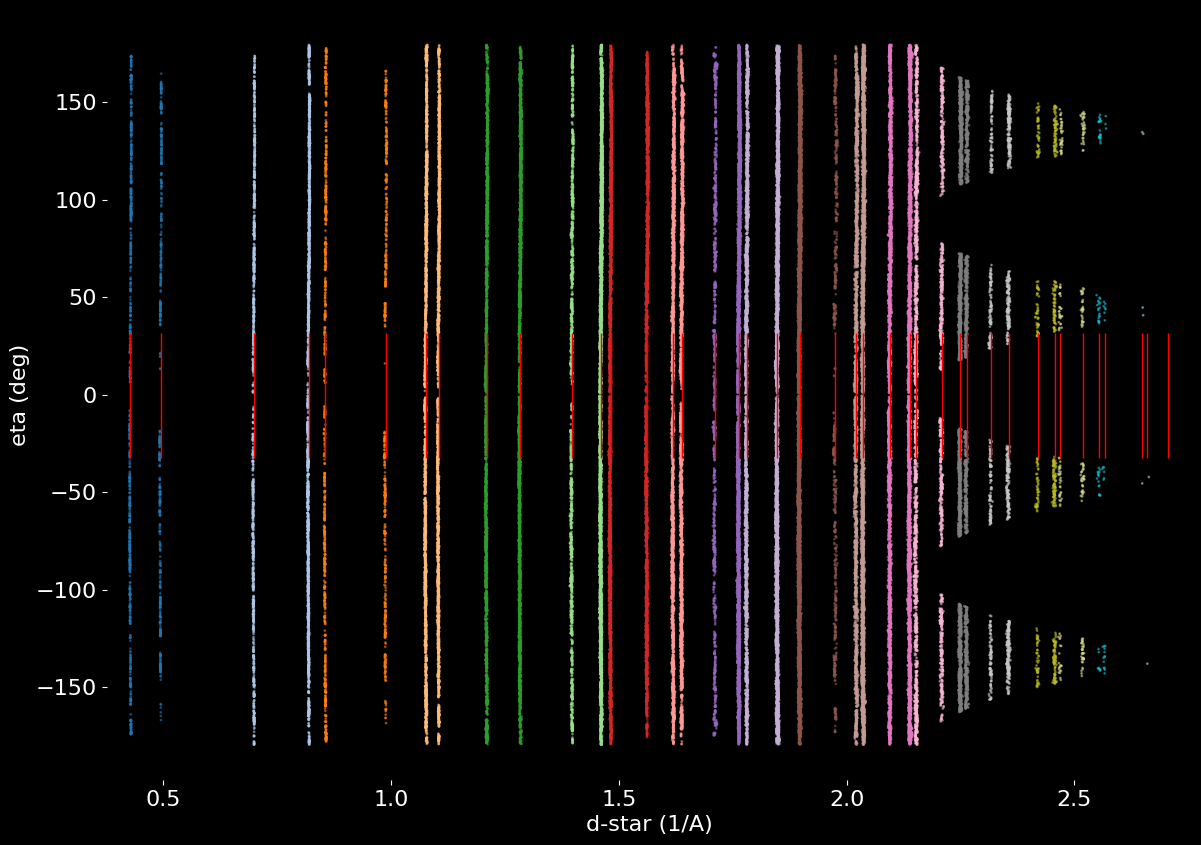

In [4]:
indexer = ImageD11.indexing.indexer_from_colfile(colf)
indexer.ds_tol = 0.01
ImageD11.indexing.loglevel = 3
indexer.assigntorings()

sample = np.random.default_rng(0).permutation(colf.nrows)[:100000]
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.scatter(colf.ds[sample], colf.eta[sample], c=indexer.ra[sample], cmap="tab20", s=1, alpha=0.5)
ax.plot(ucell.ringds, [0] * len(ucell.ringds), "|", ms=90, c="red")
ax.set_xlabel("d-star (1/A)")
ax.set_ylabel("eta (deg)")
ax.set_xlim(colf.ds.min() - 0.05, colf.ds.max() + 0.05)
plot.despine(ax)
plt.show()

## Global indexing
Peaks close to eta = 0 and 180 deg stay in diffraction condition over a wide omega range, so they are left out.

In [5]:
cf = colf.copy()
cf.filter(np.abs(cf.eta) > 10)
cf.filter(np.abs(cf.eta) < 170)

indexer = ImageD11.indexing.indexer_from_colfile(cf)
indexer.ds_tol = 0.008
indexer.assigntorings()
indexer.ring_1 = 0
indexer.ring_2 = 1
indexer.max_grains = 50
expected_peaks = (6 + 8) * 10
indexer.hkl_tol = 0.02
indexer.minpks = int(expected_peaks * 0.9)
print("minpks", indexer.minpks)
indexer.find()
indexer.scorethem()
print(f"{len(indexer.ubis)} grains found")

minpks 126


50 grains found


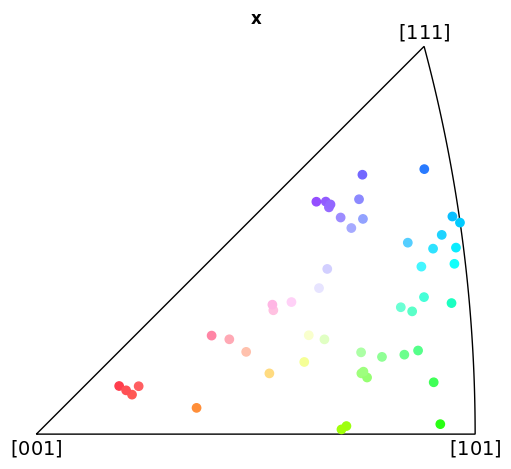

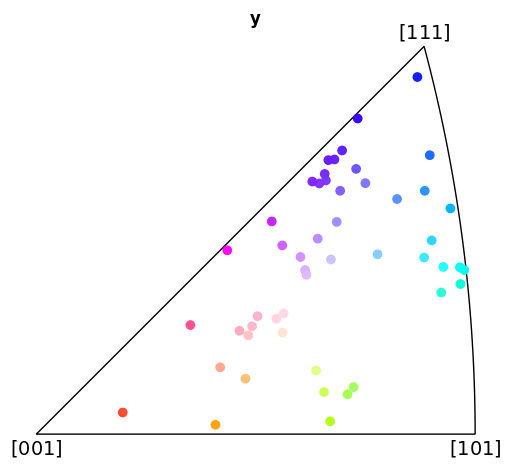

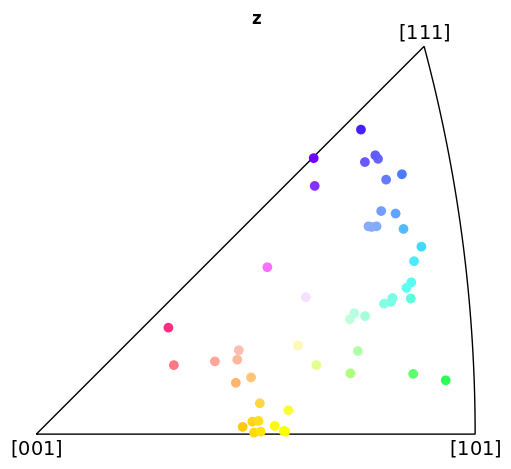

In [6]:
grains = [ImageD11.grain.grain(ubi) for ubi in indexer.ubis]
for g in grains:
    g.ref_unitcell = ucell
plt.style.use("default")
utils.plot_all_ipfs(grains)
plt.show()

## Comparison with the ground truth
The misorientation from each ground-truth mesh element to the closest indexed grain.

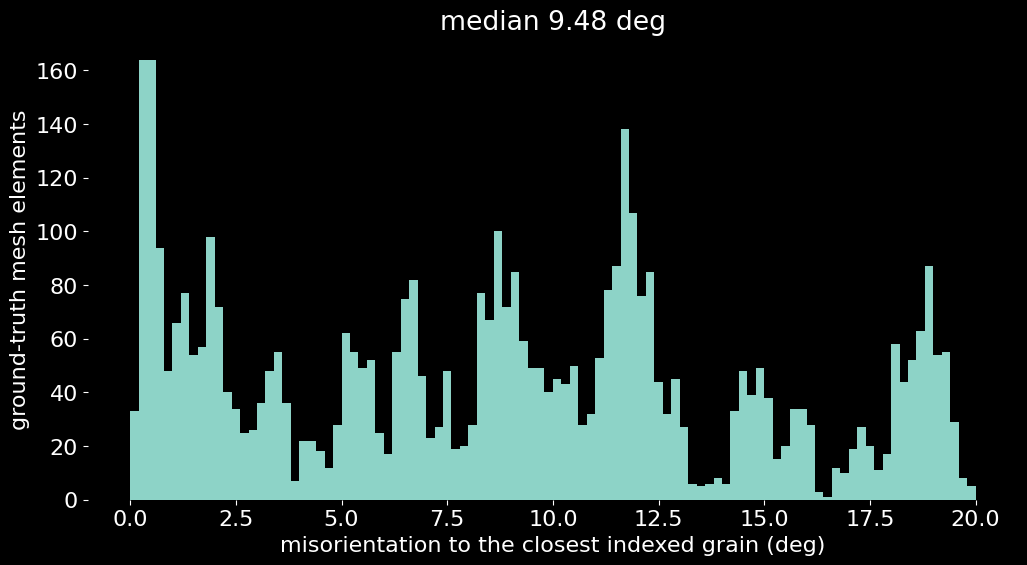

In [7]:
gt = io.read_ground_truth(SAMPLE)
rng = np.random.default_rng(0)
idx = rng.choice(len(gt["orientation"]), 5000, replace=False)

indexed_u = np.array([g.u for g in grains])
mis = orientations.min_misorientation_deg(gt["orientation"][idx], indexed_u)

plot.dark()
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.hist(mis, bins=100, range=(0, 20))
ax.set_xlabel("misorientation to the closest indexed grain (deg)")
ax.set_ylabel("ground-truth mesh elements")
ax.set_title(f"median {np.median(mis):.2f} deg")
plot.despine(ax)
plt.show()